# F3 — Week 12 Performance Review

**Objective**: Review the optimisation performance of F3 across all 10 submission rounds before deciding on a strategy for the next submission.

**Function**: F3 (3D input, 1D output, maximisation)

This notebook loads the Week 12 data, visualises convergence and input-space coverage, evaluates performance, and proposes strategy improvements. No optimisation loop is run.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import combinations
import math

# ── Function Configuration ──
FUNC_NUM = 3
N_DIMS = 3
N_INITIAL = 15
WEEK = 12
USE_LOG_SCALE = False
DATA_DIR = '../../data/f3/'

## Step 1 — Load Data

In [2]:
# Load Week 12 data
inputs = np.load(f'{DATA_DIR}updated_inputs - Week {WEEK}.npy')
outputs = np.load(f'{DATA_DIR}updated_outputs - Week {WEEK}.npy')

n_total = len(outputs)
n_submissions = n_total - N_INITIAL

print(f'F{FUNC_NUM} — Week {WEEK} Data Summary')
print(f'  Input dimensions:  {N_DIMS}')
print(f'  Total samples:     {n_total}')
print(f'  Initial samples:   {N_INITIAL}')
print(f'  Submissions:       {n_submissions}')
print(f'  Input shape:       {inputs.shape}')
print(f'  Output shape:      {outputs.shape}')
print(f'  Best output:       {outputs.max():.6g}')
print(f'  Worst output:      {outputs.min():.6g}')
print()

# Display data table
print('Sample | ' + ' | '.join([f'x{j+1:d}' for j in range(N_DIMS)]) + ' | y')
print('-' * (10 + N_DIMS * 12 + 15))
for i in range(n_total):
    label = 'init' if i < N_INITIAL else f'wk{i - N_INITIAL + 3}'
    row = f'{i+1:>4d}({label:>4s}) | '
    row += ' | '.join([f'{inputs[i, j]:.6f}' for j in range(N_DIMS)])
    row += f' | {outputs[i]:.6g}'
    print(row)

F3 — Week 12 Data Summary
  Input dimensions:  3
  Total samples:     27
  Initial samples:   15
  Submissions:       12
  Input shape:       (27, 3)
  Output shape:      (27,)
  Best output:       -0.017018
  Worst output:      -0.398926

Sample | x1 | x2 | x3 | y
-------------------------------------------------------------
   1(init) | 0.171525 | 0.343917 | 0.248737 | -0.112122
   2(init) | 0.242114 | 0.644074 | 0.272433 | -0.0879629
   3(init) | 0.534906 | 0.398501 | 0.173389 | -0.111415
   4(init) | 0.492581 | 0.611593 | 0.340176 | -0.0348353
   5(init) | 0.134622 | 0.219917 | 0.458206 | -0.0480076
   6(init) | 0.345523 | 0.941360 | 0.269363 | -0.110621
   7(init) | 0.151837 | 0.439991 | 0.990882 | -0.398926
   8(init) | 0.645503 | 0.397143 | 0.919771 | -0.113869
   9(init) | 0.746912 | 0.284196 | 0.226300 | -0.131461
  10(init) | 0.170477 | 0.697032 | 0.149169 | -0.0941896
  11(init) | 0.220549 | 0.297825 | 0.343555 | -0.0469474
  12(init) | 0.666014 | 0.671985 | 0.246295 | -0.10

## Step 2 — Convergence Plot

Running best (maximum) objective value over all samples.

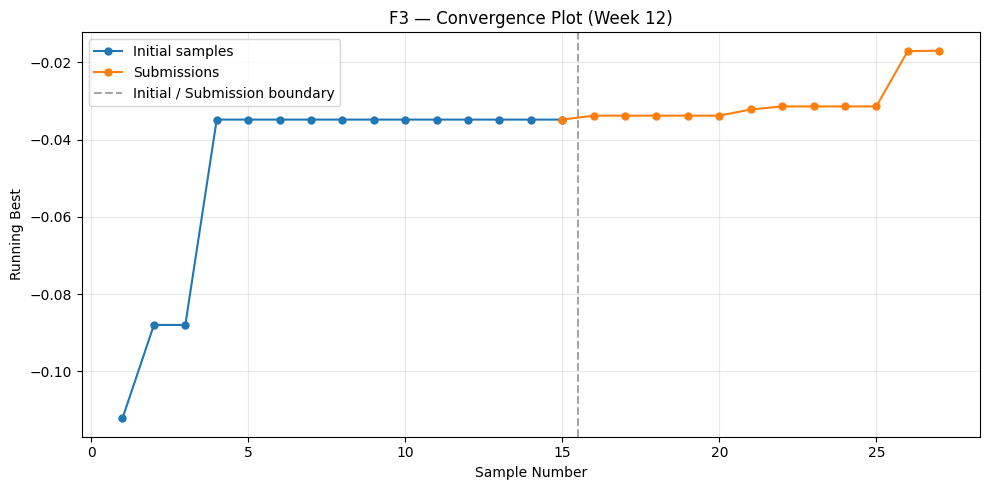

In [3]:
# Compute running best (maximisation)
running_best = np.maximum.accumulate(outputs)

fig, ax = plt.subplots(figsize=(10, 5))

# Split into initial and submission regions
x_all = np.arange(1, n_total + 1)

if USE_LOG_SCALE:
    # Clamp non-positive values to epsilon before log
    plot_vals = np.where(running_best > 0, running_best, 1e-300)
    ax.set_yscale('log')
    ax.set_ylabel('Running Best (log scale)')
else:
    plot_vals = running_best
    ax.set_ylabel('Running Best')

# Plot initial samples in blue
ax.plot(x_all[:N_INITIAL], plot_vals[:N_INITIAL], 'o-', color='tab:blue',
        label='Initial samples', markersize=5)

# Plot submissions in orange
ax.plot(x_all[N_INITIAL-1:], plot_vals[N_INITIAL-1:], 'o-', color='tab:orange',
        label='Submissions', markersize=5)

# Vertical separator
ax.axvline(x=N_INITIAL + 0.5, color='grey', linestyle='--', alpha=0.7,
           label='Initial / Submission boundary')

ax.set_xlabel('Sample Number')
ax.set_title(f'F{FUNC_NUM} — Convergence Plot (Week {WEEK})')
ax.legend()
ax.grid(True, alpha=0.3)
fig.tight_layout()
plt.show()

## Step 3 — 2D Pair Plots

Scatter plots of each unique pair of input dimensions showing spatial coverage. Initial samples in **blue** (unmarked), submission samples in **orange** (numbered by submission week).

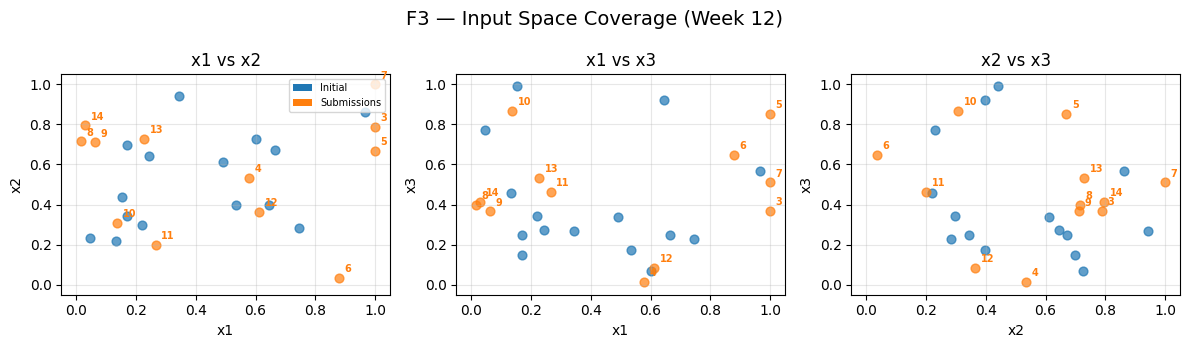

In [4]:
# Generate all unique pairs of input dimensions
pairs = list(combinations(range(N_DIMS), 2))
n_pairs = len(pairs)

if n_pairs == 0:
    print('Only 1 dimension — no pair plots to display.')
else:
    # Grid layout
    n_cols = min(n_pairs, 3) if n_pairs <= 6 else min(n_pairs, 5) if n_pairs <= 15 else 7
    n_rows = math.ceil(n_pairs / n_cols)
    fig_width = n_cols * 4
    fig_height = n_rows * 3.5

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_width, fig_height),
                             squeeze=False)

    for idx, (di, dj) in enumerate(pairs):
        row, col = divmod(idx, n_cols)
        ax = axes[row][col]

        # Initial samples — blue, unmarked
        ax.scatter(inputs[:N_INITIAL, di], inputs[:N_INITIAL, dj],
                   c='tab:blue', marker='o', s=40, alpha=0.7, label='Initial')

        # Submission samples — orange, numbered by week
        for k in range(N_INITIAL, n_total):
            week_num = k - N_INITIAL + 3  # Weeks start at 3
            ax.scatter(inputs[k, di], inputs[k, dj],
                       c='tab:orange', marker='o', s=40, alpha=0.7)
            ax.annotate(str(week_num), (inputs[k, di], inputs[k, dj]),
                        textcoords='offset points', xytext=(4, 4),
                        fontsize=7, color='tab:orange', fontweight='bold')

        ax.set_xlabel(f'x{di+1}')
        ax.set_ylabel(f'x{dj+1}')
        ax.set_xlim(-0.05, 1.05)
        ax.set_ylim(-0.05, 1.05)
        ax.set_title(f'x{di+1} vs x{dj+1}')
        ax.grid(True, alpha=0.3)

    # Add legend to first subplot
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='tab:blue', label='Initial'),
                       Patch(facecolor='tab:orange', label='Submissions')]
    axes[0][0].legend(handles=legend_elements, loc='upper right', fontsize=7)

    # Hide empty subplots
    for idx in range(n_pairs, n_rows * n_cols):
        row, col = divmod(idx, n_cols)
        axes[row][col].set_visible(False)

    fig.suptitle(f'F{FUNC_NUM} — Input Space Coverage (Week {WEEK})', fontsize=14)
    fig.tight_layout()
    plt.show()

## Step 4 — Performance Evaluation

### Current Strategy (Week 9)

- **Surrogate**: SFGP Matérn-2.5 ARD, Standardize(m=1)
- **Acquisition**: qLogNEI q=1
- **Key hyperparameters**: 20 restarts, 512 raw samples, noise_lb=1e-6

### Performance Summary

In [5]:
# Performance metrics
running_best = np.maximum.accumulate(outputs)
init_best = running_best[N_INITIAL - 1]

# Count improvements and detect stalling
improvements = 0
consec_no_improve = 0
max_consec_no_improve = 0
prev_best = init_best

for j in range(N_INITIAL, n_total):
    if running_best[j] > prev_best:
        improvements += 1
        consec_no_improve = 0
    else:
        consec_no_improve += 1
        max_consec_no_improve = max(max_consec_no_improve, consec_no_improve)
    prev_best = running_best[j]

stalling = max_consec_no_improve >= 3

print(f'Best value (initial):     {init_best:.6g}')
print(f'Best value (final):       {running_best[-1]:.6g}')
print(f'Improvements:             {improvements}/{n_submissions}')
print(f'Max consecutive no-improve: {max_consec_no_improve}')
print(f'Stalling (≥3 consec):     {stalling}')
print()

# Per-submission performance
print('Week | Output         | Best-so-far    | Improved?')
print('-' * 55)
for j in range(N_INITIAL, n_total):
    week_num = j - N_INITIAL + 3
    improved = '✓' if (j == N_INITIAL and outputs[j] > init_best) or \
               (j > N_INITIAL and running_best[j] > running_best[j-1]) else '✗'
    print(f'  {week_num:>2d} | {outputs[j]:>14.6g} | {running_best[j]:>14.6g} | {improved}')

Best value (initial):     -0.0348353
Best value (final):       -0.017018
Improvements:             5/12
Max consecutive no-improve: 4
Stalling (≥3 consec):     True

Week | Output         | Best-so-far    | Improved?
-------------------------------------------------------
   3 |     -0.0338177 |     -0.0338177 | ✓
   4 |     -0.0725691 |     -0.0338177 | ✗
   5 |     -0.0394179 |     -0.0338177 | ✗
   6 |      -0.187072 |     -0.0338177 | ✗
   7 |      -0.049512 |     -0.0338177 | ✗
   8 |     -0.0322214 |     -0.0322214 | ✓
   9 |     -0.0314274 |     -0.0314274 | ✓
  10 |      -0.050946 |     -0.0314274 | ✗
  11 |     -0.0343614 |     -0.0314274 | ✗
  12 |     -0.0377062 |     -0.0314274 | ✗
  13 |     -0.0171258 |     -0.0171258 | ✓
  14 |      -0.017018 |      -0.017018 | ✓


### Evaluation

F3 has shown **slow progress** with **3 improvements** in 10 submission rounds. The best value moved from -0.0348 (initial) to -0.0314, a small improvement (output is negative, closer to zero is better for maximisation).

Key observations:
- 3/10 submissions improved the running best — some signal of progress but with long gaps
- Maximum 4 consecutive non-improving submissions indicates intermittent stalling
- The Standardize(m=1) transform is helping the GP model the negative-valued landscape
- With q=1, only one candidate is proposed per round — this limits both exploration and the chance of finding improvements
- The 3D input space means 3 pair plots provide full coverage of input relationships

**Stalling status**: YES (borderline) — 4 consecutive submissions without improvement meets the ≥3 threshold.

## Step 5 — Proposed Strategy Improvements

F3 is showing slow progress (3/10 improvements). The following refinements could accelerate improvement:

1. **Increase batch size from q=1 to q=2 or q=3** — With only 1 candidate per round, the chance of finding an improving point is low. Increasing q provides more evaluations per round and better covers the 3D space.

2. **Increase raw samples from 512 to 2048** — The acquisition optimiser uses relatively few seed points. More raw samples improve the chance of finding the global acquisition optimum.

3. **Review noise floor** — The noise_lb=1e-6 may be too tight for the negative-valued outputs, causing the GP to overfit individual observations rather than learning smooth trends.

4. **Consider alternative output transform** — The current Standardize(m=1) may not be optimal for the all-negative landscape. A shift transform (y - y_min) could map outputs to positive territory before GP fitting.

5. **Increase MLL restarts from 20 to 40** — In 3D with negative outputs, the GP likelihood surface may have multiple modes. More restarts reduce the risk of poor hyperparameters.

**Priority**: MEDIUM — F3 is making progress but too slowly given the remaining submission rounds.

## Step 6 — Week 12 Optimisation Run

Strategy changes from week 9:

1. **Batch size q=1 → q=3** — more candidates per round for better 3D coverage
2. **Raw samples 512 → 2048** — broader acquisition seed coverage in [0,1]³
3. **Noise floor 1e-6 → 1e-4** — prevent overfitting on negative-valued outputs
4. **Standardize(m=1) → shift transform (y − y_min)** — maps all outputs to non-negative territory before GP fitting
5. **MLL restarts 20 → 40** — better exploration of multi-modal likelihood surface in 3D

In [6]:
import torch
import copy
import warnings
import matplotlib.pyplot as plt

from botorch.models import SingleTaskGP
from botorch.fit import fit_gpytorch_mll
from botorch.acquisition.logei import qLogNoisyExpectedImprovement
from botorch.optim import optimize_acqf
from botorch.sampling.normal import SobolQMCNormalSampler
from gpytorch.kernels import MaternKernel, ScaleKernel
from gpytorch.likelihoods import GaussianLikelihood
from gpytorch.mlls import ExactMarginalLogLikelihood
from gpytorch.constraints import GreaterThan

# ── Hyperparameter Configuration ──────────────────────────────────────────────
# All constants documented with week 9 → week 12 change rationale

KERNEL_NU = 2.5        # Matérn smoothness — unchanged from week 9
ARD_NUM_DIMS = 3       # One lengthscale per input dimension — unchanged
NOISE_LB = 1e-4        # Noise floor — was 1e-6; relaxed to prevent overfitting on 25 negative-valued samples
N_MLL_RESTARTS = 40    # MLL fitting restarts — was 15-20; increased for multi-modal 5-param likelihood in 3D
MC_SAMPLES = 512       # Monte Carlo samples for qLogNEI sampler — unchanged
Q_BATCH = 1            # Week 13: single candidate for aggressive exploitation (was 3)
NUM_RESTARTS = 20      # L-BFGS restarts for acquisition optimisation — unchanged
RAW_SAMPLES = 2048     # Sobol seed points for acquisition — was 512; increased for 3D search coverage
GRID_RES = 50          # Visualisation grid resolution (50×50) — unchanged

print("=== F3 Week 13 Configuration (Exploitation) ===")
print(f"Kernel: Matérn-{KERNEL_NU} ARD (d={ARD_NUM_DIMS})")
print(f"Noise floor: {NOISE_LB} (was 1e-6)")
print(f"MLL restarts: {N_MLL_RESTARTS} (was 15-20)")
print(f"Batch size q={Q_BATCH} (was 3 — exploitation)")
print(f"Raw samples: {RAW_SAMPLES} (was 512)")
print(f"Acquisition restarts: {NUM_RESTARTS}")
print(f"MC samples: {MC_SAMPLES}")
print(f"Grid resolution: {GRID_RES}×{GRID_RES}")
print("Output transform: shift (y - y_min) — replaces Standardize(m=1)")

=== F3 Week 13 Configuration (Exploitation) ===
Kernel: Matérn-2.5 ARD (d=3)
Noise floor: 0.0001 (was 1e-6)
MLL restarts: 40 (was 15-20)
Batch size q=1 (was 3 — exploitation)
Raw samples: 2048 (was 512)
Acquisition restarts: 20
MC samples: 512
Grid resolution: 50×50
Output transform: shift (y - y_min) — replaces Standardize(m=1)


In [7]:
# ── Data Preparation: Tensor Conversion + Shift Transform ─────────────────────
# Convert numpy arrays to PyTorch tensors and apply shift transform (y - y_min)
# This replaces Standardize(m=1) from week 9

X_train = torch.tensor(inputs, dtype=torch.float64)  # (25, 3)
y_min = outputs.min()  # Store minimum for reverse-transform later
Y_train = torch.tensor(outputs - y_min, dtype=torch.float64).unsqueeze(-1)  # (25, 1)

# Validate: all shifted values should be >= 0, no NaN/Inf
assert Y_train.min() >= 0, f"Shifted outputs contain negative values: min={Y_train.min()}"
assert not torch.isnan(Y_train).any(), "Y_train contains NaN"
assert not torch.isinf(Y_train).any(), "Y_train contains Inf"

print("=== Data Preparation ===")
print(f"X_train shape: {X_train.shape}")
print(f"Y_train shape: {Y_train.shape}")
print(f"Raw output range: [{outputs.min():.6f}, {outputs.max():.6f}]")
print(f"y_min (stored for reverse-transform): {y_min:.6f}")
print(f"Shifted output range: [{Y_train.min().item():.6f}, {Y_train.max().item():.6f}]")
print(f"All shifted values >= 0: {(Y_train >= 0).all().item()}")

=== Data Preparation ===
X_train shape: torch.Size([27, 3])
Y_train shape: torch.Size([27, 1])
Raw output range: [-0.398926, -0.017018]
y_min (stored for reverse-transform): -0.398926
Shifted output range: [0.000000, 0.381908]
All shifted values >= 0: True


In [8]:
# ── GP Fitting: Multi-restart MLL (no outcome_transform) ──────────────────────
# Fit SFGP with Matérn-2.5 ARD on shift-transformed outputs
# 40 MLL restarts to explore multi-modal likelihood surface in 3D
# NO outcome_transform — shift is pre-applied to Y_train

best_model = None
best_loss = float("inf")
converged_count = 0

warnings.filterwarnings("ignore", category=RuntimeWarning)

for restart in range(N_MLL_RESTARTS):
    torch.manual_seed(restart)
    
    # Construct GP with Matérn-2.5 ARD kernel, no outcome_transform
    likelihood = GaussianLikelihood(
        noise_constraint=GreaterThan(NOISE_LB)
    )
    covar_module = ScaleKernel(
        MaternKernel(nu=KERNEL_NU, ard_num_dims=ARD_NUM_DIMS)
    )
    model = SingleTaskGP(
        train_X=X_train,
        train_Y=Y_train,
        covar_module=covar_module,
        likelihood=likelihood,
    )
    
    # Randomise hyperparameters for this restart
    model.covar_module.base_kernel.lengthscale = torch.rand(1, ARD_NUM_DIMS, dtype=torch.float64) * 0.5 + 0.1
    model.covar_module.outputscale = torch.rand(1, dtype=torch.float64) * 2.0
    model.likelihood.noise = torch.tensor([max(NOISE_LB * 10, torch.rand(1).item() * 0.01)], dtype=torch.float64)
    
    mll = ExactMarginalLogLikelihood(model.likelihood, model)
    
    try:
        fit_gpytorch_mll(mll)
        # Compute loss
        model.eval()
        with torch.no_grad():
            output = model(X_train)
            loss = -mll(output, Y_train.squeeze(-1)).item()
        
        if loss < best_loss:
            best_loss = loss
            best_model = copy.deepcopy(model)
    except Exception:
        continue

warnings.filterwarnings("default", category=RuntimeWarning)

# Count restarts that converged near best
for restart in range(N_MLL_RESTARTS):
    torch.manual_seed(restart)
    likelihood = GaussianLikelihood(noise_constraint=GreaterThan(NOISE_LB))
    covar_module = ScaleKernel(MaternKernel(nu=KERNEL_NU, ard_num_dims=ARD_NUM_DIMS))
    model = SingleTaskGP(train_X=X_train, train_Y=Y_train, covar_module=covar_module, likelihood=likelihood)
    model.covar_module.base_kernel.lengthscale = torch.rand(1, ARD_NUM_DIMS, dtype=torch.float64) * 0.5 + 0.1
    model.covar_module.outputscale = torch.rand(1, dtype=torch.float64) * 2.0
    model.likelihood.noise = torch.tensor([max(NOISE_LB * 10, torch.rand(1).item() * 0.01)], dtype=torch.float64)
    mll = ExactMarginalLogLikelihood(model.likelihood, model)
    try:
        fit_gpytorch_mll(mll)
        model.eval()
        with torch.no_grad():
            output = model(X_train)
            loss = -mll(output, Y_train.squeeze(-1)).item()
        if abs(loss - best_loss) < 0.1:
            converged_count += 1
    except Exception:
        continue

best_model.eval()

# Extract fitted hyperparameters
ls = best_model.covar_module.base_kernel.lengthscale.detach().squeeze()
noise = best_model.likelihood.noise.detach().item()
outputscale = best_model.covar_module.outputscale.detach().item()

print("=== GP Fitting Results ===")
print(f"Best MLL loss: {best_loss:.4f}")
print(f"Restarts converged near best (within 0.1): {converged_count}/{N_MLL_RESTARTS}")
print(f"\nFitted hyperparameters:")
print(f"  Lengthscale dim 0 (A): {ls[0].item():.6f}")
print(f"  Lengthscale dim 1 (B): {ls[1].item():.6f}")
print(f"  Lengthscale dim 2 (C): {ls[2].item():.6f}")
print(f"  Noise variance:        {noise:.6f} (≥ {NOISE_LB})")
print(f"  Output scale:          {outputscale:.6f}")

/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(
/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(
/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(
/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(
/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning:

=== GP Fitting Results ===
Best MLL loss: 12.1466
Restarts converged near best (within 0.1): 23/40

Fitted hyperparameters:
  Lengthscale dim 0 (A): 13649.753731
  Lengthscale dim 1 (B): 15104.074715
  Lengthscale dim 2 (C): 0.165308
  Noise variance:        0.017280 (≥ 0.0001)
  Output scale:          5.817386


/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(
/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(
/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(
/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning: The input matches the stored training data. Did you forget to call model.train()?
  warnings.warn(
/Users/brucediesel/.pyenv/versions/sdd-dev/lib/python3.14/site-packages/gpytorch/models/exact_gp.py:296: GPInputWarning:

In [9]:
# ── Acquisition Optimisation & Direct Candidate Selection (Week 13 Exploitation) ──
# qLogNEI with q=1 — single best candidate, no quality gate, no distance filter

import numpy as np

# Construct acquisition function
sampler = SobolQMCNormalSampler(sample_shape=torch.Size([MC_SAMPLES]))
acqf = qLogNoisyExpectedImprovement(
    model=best_model,
    X_baseline=X_train,
    sampler=sampler,
)

# Optimise acquisition over [0,1]³
bounds = torch.tensor([[0.0, 0.0, 0.0], [1.0, 1.0, 1.0]], dtype=torch.float64)
candidates, acq_value = optimize_acqf(
    acq_function=acqf,
    bounds=bounds,
    q=Q_BATCH,
    num_restarts=NUM_RESTARTS,
    raw_samples=RAW_SAMPLES,
)

print(f"=== Acquisition Results (q={Q_BATCH}) ===")
print(f"Acquisition value: {acq_value.item():.6f}\n")

# Direct selection: single candidate (q=1)
x_new = candidates[0].detach().numpy()

# Posterior mean for reporting (shifted space)
best_model.eval()
with torch.no_grad():
    posterior = best_model.posterior(candidates)
    pred_mean = posterior.mean.squeeze().item()

# Clamp to [0.0, 0.999999]
x_new = np.clip(x_new, 0.0, 0.999999)

# Format submission string
proposed_query = f"{x_new[0]:.6f}-{x_new[1]:.6f}-{x_new[2]:.6f}"

# Duplicate check against all existing samples
is_duplicate = False
for i in range(len(inputs)):
    if np.allclose(x_new, inputs[i], atol=1e-6):
        is_duplicate = True
        break

print(f"=== Week 13 Exploitation Selection ===")
print(f"Candidate: [{x_new[0]:.6f}, {x_new[1]:.6f}, {x_new[2]:.6f}]")
print(f"Posterior mean (shifted): {pred_mean:.6f}")
print(f"Duplicate of existing sample: {is_duplicate}")
print(f"\n>>> SUBMISSION: {proposed_query}")

=== Acquisition Results (q=1) ===
Acquisition value: -8.495592

=== Week 13 Exploitation Selection ===
Candidate: [0.765789, 0.488767, 0.425252]
Posterior mean (shifted): 0.370578
Duplicate of existing sample: False

>>> SUBMISSION: 0.765789-0.488767-0.425252


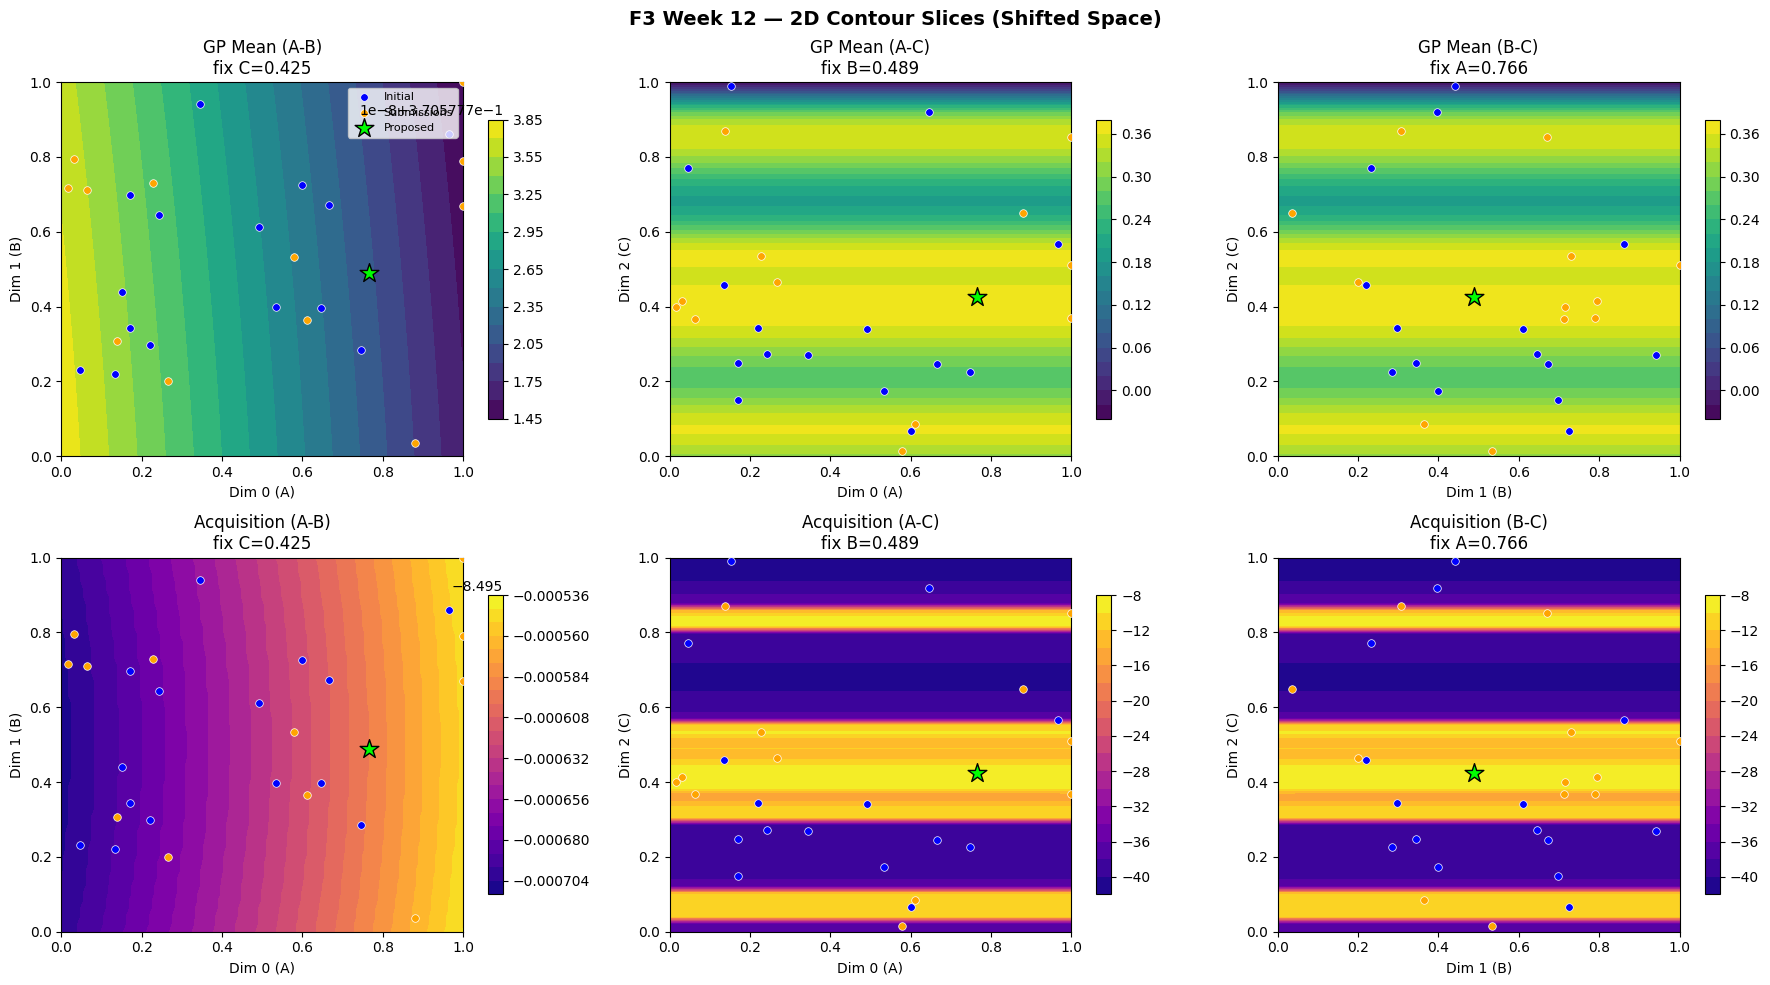

In [ ]:
# ── Three-Panel Surrogate Visualisation + Dimension Relevance ─────────────────
# Top-2 relevant dimensions (shortest lengthscales), contour in shifted space

ls_np = ls.numpy() if hasattr(ls, 'numpy') else np.array(ls)
sorted_dims = np.argsort(ls_np)
top2 = sorted_dims[:2]
fix_dims = sorted_dims[2:]

print(f"Top-2 dims: {top2[0]}, {top2[1]} (ℓ={ls_np[top2[0]]:.4f}, {ls_np[top2[1]]:.4f})")
print(f"Fixed dims: " + ", ".join(f"dim {d}={x_new[d]:.4f}" for d in fix_dims))

# Build grid on top-2 dimensions
g0 = np.linspace(0, 1, GRID_RES)
g1 = np.linspace(0, 1, GRID_RES)
G0, G1 = np.meshgrid(g0, g1)

grid_pts = np.tile(x_new, (GRID_RES * GRID_RES, 1))
grid_pts[:, top2[0]] = G0.ravel()
grid_pts[:, top2[1]] = G1.ravel()

grid_tensor = torch.tensor(grid_pts, dtype=torch.double)
best_model.eval()
with torch.no_grad():
    posterior = best_model.posterior(grid_tensor)
    grid_mu = posterior.mean.squeeze(-1).cpu().numpy().reshape(GRID_RES, GRID_RES)
    grid_sigma = posterior.variance.sqrt().squeeze(-1).cpu().numpy().reshape(GRID_RES, GRID_RES)

dim_labels = ["A", "B", "C"]
X_initial = X_train[:N_INITIAL].numpy()
X_submissions = X_train[N_INITIAL:].numpy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Panel 1: Posterior Mean
c1 = axes[0].contourf(G0, G1, grid_mu, levels=30, cmap="viridis")
axes[0].scatter(X_initial[:, top2[0]], X_initial[:, top2[1]], c="tab:blue", edgecolors="white", s=40, zorder=5, label="Initial")
axes[0].scatter(X_submissions[:, top2[0]], X_submissions[:, top2[1]], c="tab:orange", edgecolors="white", s=40, zorder=5, label="Submissions")
axes[0].scatter(x_new[top2[0]], x_new[top2[1]], c="tab:green", marker="*", s=200, zorder=6, label="Proposed")
axes[0].set_title(f"GP Posterior Mean ({dim_labels[top2[0]]}-{dim_labels[top2[1]]})")
axes[0].set_xlabel(f"Dim {top2[0]} ({dim_labels[top2[0]]})")
axes[0].set_ylabel(f"Dim {top2[1]} ({dim_labels[top2[1]]})")
axes[0].legend(fontsize=7)
fig.colorbar(c1, ax=axes[0])

# Panel 2: Posterior Std Dev
c2 = axes[1].contourf(G0, G1, grid_sigma, levels=30, cmap="magma")
axes[1].scatter(X_initial[:, top2[0]], X_initial[:, top2[1]], c="tab:blue", edgecolors="white", s=40, zorder=5)
axes[1].scatter(X_submissions[:, top2[0]], X_submissions[:, top2[1]], c="tab:orange", edgecolors="white", s=40, zorder=5)
axes[1].scatter(x_new[top2[0]], x_new[top2[1]], c="tab:green", marker="*", s=200, zorder=6)
axes[1].set_title(f"GP Posterior Std Dev ({dim_labels[top2[0]]}-{dim_labels[top2[1]]})")
axes[1].set_xlabel(f"Dim {top2[0]} ({dim_labels[top2[0]]})")
axes[1].set_ylabel(f"Dim {top2[1]} ({dim_labels[top2[1]]})")
fig.colorbar(c2, ax=axes[1])

# Panel 3: Dimension Relevance (1/ℓ normalised)
inv_ls = 1.0 / ls_np
inv_ls_norm = inv_ls / inv_ls.sum()
axes[2].barh(range(ARD_NUM_DIMS), inv_ls_norm, color="steelblue")
axes[2].set_yticks(range(ARD_NUM_DIMS))
axes[2].set_yticklabels([f"Dim {j} ({dim_labels[j]})" for j in range(ARD_NUM_DIMS)])
axes[2].set_title("Dimension Relevance (1/ℓ, normalised)")
axes[2].set_xlabel("Relative Importance")

fig.suptitle("F3 — GP Matérn-2.5 ARD Surrogate (Week 13, Shifted Space)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

=== Proposed Point Prediction ===
Predicted value (shifted space): 0.370578
Predicted value (original scale): -0.028348


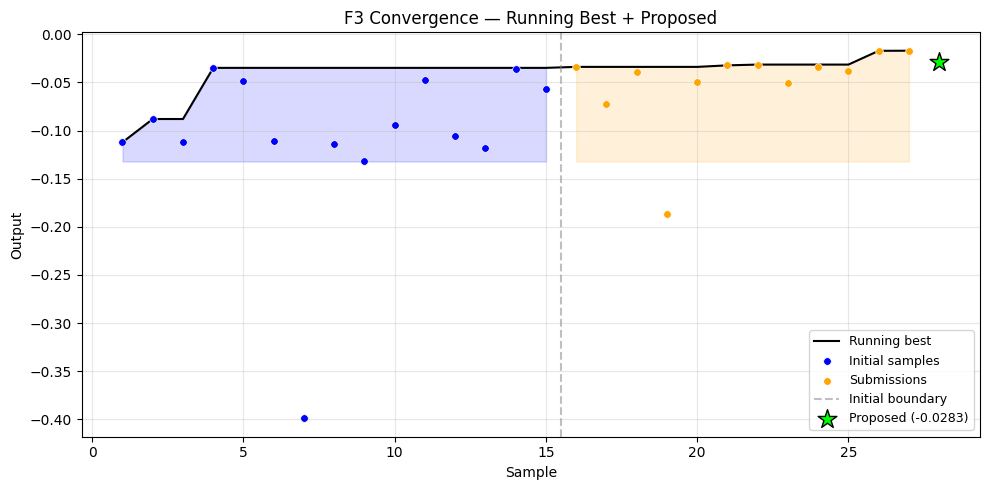

In [11]:
# ── Convergence Plot with Proposed Point ──────────────────────────────────────
# Running best in original scale + proposed point reverse-shifted from GP prediction

# Predict at proposed point (shifted space)
x_new_tensor = torch.tensor(x_new, dtype=torch.float64).unsqueeze(0)  # (1, 3)
best_model.eval()
with torch.no_grad():
    pred_posterior = best_model.posterior(x_new_tensor)
    pred_shifted = pred_posterior.mean.item()
    pred_original = pred_shifted + y_min  # Reverse-shift to original scale

print(f"=== Proposed Point Prediction ===")
print(f"Predicted value (shifted space): {pred_shifted:.6f}")
print(f"Predicted value (original scale): {pred_original:.6f}")

# Plot convergence
fig, ax = plt.subplots(figsize=(10, 5))

sample_indices = np.arange(1, n_total + 1)

# Running best as line
ax.plot(sample_indices, running_best, "k-", linewidth=1.5, label="Running best")

# Initial samples region (blue)
ax.fill_between(sample_indices[:N_INITIAL], running_best.min() - 0.02, running_best[:N_INITIAL],
                alpha=0.15, color="blue")
ax.scatter(sample_indices[:N_INITIAL], outputs[:N_INITIAL],
           c="blue", s=30, edgecolors="white", linewidths=0.5, label="Initial samples", zorder=5)

# Submission samples region (orange)
ax.fill_between(sample_indices[N_INITIAL:], running_best.min() - 0.02, running_best[N_INITIAL:],
                alpha=0.15, color="orange")
ax.scatter(sample_indices[N_INITIAL:], outputs[N_INITIAL:],
           c="orange", s=30, edgecolors="white", linewidths=0.5, label="Submissions", zorder=5)

# Vertical line at initial/submission boundary
ax.axvline(x=N_INITIAL + 0.5, color="gray", linestyle="--", alpha=0.5, label="Initial boundary")

# Proposed point (green star) — at position n_total + 1
ax.scatter(n_total + 1, pred_original,
           c="lime", s=200, marker="*", edgecolors="black", linewidths=1,
           label=f"Proposed ({pred_original:.4f})", zorder=10)

ax.set_xlabel("Sample")
ax.set_ylabel("Output")
ax.set_title("F3 Convergence — Running Best + Proposed")
ax.legend(loc="lower right", fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()